# ResoKit basic example

This notebook is an example usage of the ResoKit package.

We will download a dataset and analyze the system Kepler-55.
This is a 5 planets and 2 stars system.

---

## Import ResoKit and the necessary packages

In [1]:
import resokit as rk
import matplotlib.pyplot as plt

## Download the datasets

### EU dataset

In [2]:
rk.datasets.download("eu")

Checking local dataset from which='eu' source...
 File from which='eu' source to check if outdated not found.
 Note: Progress is shown at every 0.15 MB
 Data downloaded successfully. (3.39 MB)
Creating the ZIP archive /home/egianuzzi/.resokit_data/exoplanet_eu.zip...
 Written exoplanet_eu.csv to /home/egianuzzi/.resokit_data/exoplanet_eu.zip.
Updated stored index in memory.
Stored dataset in memory.


PosixPath('/home/egianuzzi/.resokit_data/exoplanet_eu.zip/exoplanet_eu.csv')

### Binary stars datasets

In [5]:
rk.datasets.download_binary("all", return_data=False)

 Note: Progress is shown at every 0.01 KB
 Data downloaded successfully. (57.856 KB)
 Creating the file /home/egianuzzi/.resokit_data/plan_bin500aun.txt...
 Written /home/egianuzzi/.resokit_data/plan_bin500aun.txt.
 Stored the type-s dataset in memory.
 Note: Progress is shown at every 0.01 KB
 Data downloaded successfully. (5.304 KB)
 Creating the file /home/egianuzzi/.resokit_data/plan_circ.txt...
 Written /home/egianuzzi/.resokit_data/plan_circ.txt.
 Stored the type-p dataset in memory.


{'s': PosixPath('/home/egianuzzi/.resokit_data/plan_bin500aun.txt'),
 'p': PosixPath('/home/egianuzzi/.resokit_data/plan_circ.txt')}

## Load the system

In [ ]:
kepler55 = rk.load.from_eu("Kepler-55", exact_match=False)

Looking for star system 'Kepler-55' in eu database.
 Loaded full dataset from memory stored datasets.
 Found a very close star match: 'Kepler-55 A' in eu dataset.
 Loading the almost exact match...
Checking if 'Kepler-55 A' is a binary system...
 Binary system found in ['Kepler55'], in s-type binary orbit.
Creating system 'Kepler-55'.
 Using binary star 'Kepler-55'.
 5 planets created.


In [7]:
kepler55

StaticSystem: 'Kepler-55'
 Star 1:
  Kepler-55 A 
 Planets:
  Kepler-55 Ad
  Kepler-55 Ae
  Kepler-55 Af
  Kepler-55 Ab
  Kepler-55 Ac
 Star 2:
  Kepler-55 B
 [binary system]
from 'eu' data source.

## Examination

### Masses

In [8]:
masses = kepler55.get_item("mass", error=True)
masses

,mass,mass_err_min,mass_err_max
Kepler-55 Ad,NaN,NaN,NaN
Kepler-55 Ae,NaN,NaN,NaN
Kepler-55 Af,NaN,NaN,NaN
Kepler-55 Ab,0.1353,0.0570,0.1170
Kepler-55 Ac,0.2196,0.0576,0.1026


### Radii

In [9]:
radii = kepler55.get_item("radius", error=True)
radii

,radius,radius_err_min,radius_err_max
Kepler-55 Ad,0.1650,0.0045,0.0116
Kepler-55 Ae,0.1445,0.0045,0.0098
Kepler-55 Af,0.1561,0.0054,0.0098
Kepler-55 Ab,0.1700,0.0054,0.0116
Kepler-55 Ac,0.1650,0.0045,0.0116


### Periods

##### Planets

In [ ]:
periods = kepler55.get_item("P", error=True)
periods

,P,P_err_min,P_err_max
Kepler-55 Ad,2.211117,0.000003,0.000003
Kepler-55 Ae,4.617491,0.000009,0.000009
Kepler-55 Af,10.198493,0.000032,0.000032
Kepler-55 Ab,27.954134,0.000173,0.000173
Kepler-55 Ac,42.140609,0.000314,0.000314


##### Binary

In [13]:
kepler55.star.P

np.float64(35115382.724187925)

## Estimations

#### Period ratios

In [19]:
kepler55.period_ratios_

,Kepler-55 Ad,Kepler-55 Ae,Kepler-55 Af,Kepler-55 Ab,Kepler-55 Ac,Kepler-55 B
Kepler-55 Ad,1.000000e+00,2.088307e+00,4.612371e+00,1.264254e+01,19.058516,1.588129e+07
Kepler-55 Ae,4.788569e-01,1.000000e+00,2.208666e+00,6.053967e+00,9.126301,7.604863e+06
Kepler-55 Af,2.168082e-01,4.527621e-01,1.000000e+00,2.741006e+00,4.132043,3.443193e+06
Kepler-55 Ab,7.909803e-02,1.651810e-01,3.648295e-01,1.000000e+00,1.507491,1.256179e+06
Kepler-55 Ac,5.246998e-02,1.095734e-01,2.420110e-01,6.633538e-01,1.000000,8.332908e+05
Kepler-55 B,6.296719e-08,1.314948e-07,2.904281e-07,7.960652e-07,0.000001,1.000000e+00


In [29]:
kepler55.pair_ratio(max_iter=2, use_binary=False, verbose=False)

,Kepler-55 Ad,Kepler-55 Ae,Kepler-55 Af,Kepler-55 Ab,Kepler-55 Ac
Kepler-55 Ad,"(1, 1)","(23, 11)","(5, 1)","(13, 1)","(324, 17)"
Kepler-55 Ae,"(1, 2)","(1, 1)","(9, 4)","(109, 18)","(64, 7)"
Kepler-55 Af,"(1, 4)","(1, 2)","(1, 1)","(3, 1)","(29, 7)"
Kepler-55 Ab,"(1, 12)","(1, 6)","(1, 2)","(1, 1)","(2, 1)"
Kepler-55 Ac,"(1, 19)","(1, 9)","(1, 4)","(1, 1)","(1, 1)"


#### Mass estimation

In [35]:
kepler55.estimate_mass(err_method=2)

,mass,mass_err_min,mass_err_max
Kepler-55 Ad,0.012377,0.000568,0.001513
Kepler-55 Ae,0.009881,0.000517,0.001164
Kepler-55 Af,0.011265,0.000654,0.001227
Kepler-55 Ab,0.135300,0.057000,0.117000
Kepler-55 Ac,0.219600,0.057600,0.102600


#### Hill radii estimation

In [42]:
kepler55.estimate_hill_radius(deep_estimate=True, circular=True)

Kepler-55 Ad    0.000525
Kepler-55 Ae    0.000796
Kepler-55 Af    0.001410
Kepler-55 Ab    0.006317
Kepler-55 Ac    0.009763
Name: hill, dtype: float64

## Plotting

#### Mass-Radius

In [47]:
# First, we create a mock-system with estimated masses (to avoid NaNs)
k55_mock = kepler55.estimate_mass(new_system=True)

Setting mass to 0.012377252190157345 in planet Kepler-55 Ad.
Setting mass to 0.009881071481254833 in planet Kepler-55 Ae.
Setting mass to 0.011265218506422266 in planet Kepler-55 Af.
Setting mass to 0.1353 in planet Kepler-55 Ab.
Setting mass to 0.2196 in planet Kepler-55 Ac.


Text(0, 0.5, 'Radius (R$_J$)')

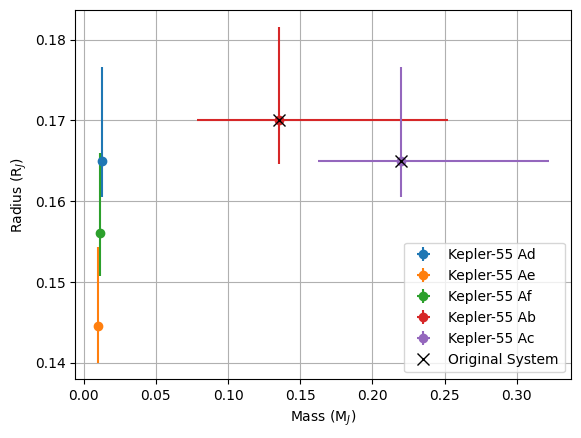

In [72]:
ax = k55_mock.plot("mass", "radius", error_x=True, error_y=True)
kepler55.plot("mass", "radius", label="Original System", 
              plot_kwargs={"fmt":"x", "color":"black", "ms":8})
ax.legend(loc=4)
ax.grid()
ax.set_xlabel("Mass (M$_J$)")
ax.set_ylabel("Radius (R$_J$)")

#### Period ratios

Text(0, 0.5, 'Period Ratio ($P_{i+1}/P_i$)')

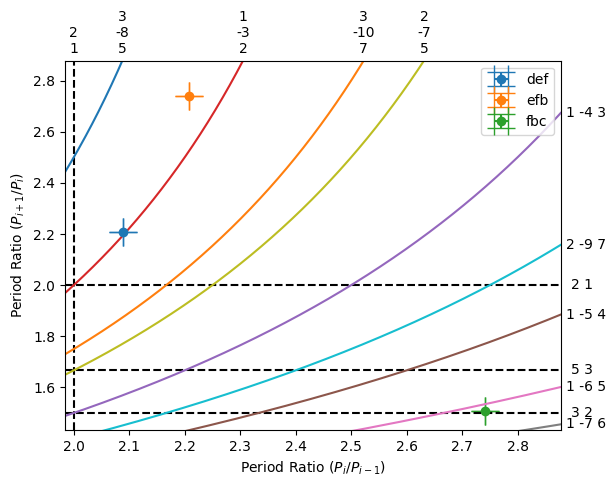

In [44]:
ax = kepler55.plot_triplet(error=True, capsize=10)
ax.legend()
ax.set_xlabel("Period Ratio ($P_i/P_{i-1}$)")
ax.set_ylabel("Period Ratio ($P_{i+1}/P_i$)")